## PDSPLs Pairing

In [1]:
import numpy as np
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM

# PDSPL Utils Imports
from pdspl_utils.pairing import (
    get_kdtree_pairs, 
    get_pairs_table_PDSPL, 
    compute_dissimilarity,
    plot_beta_E_vs_D_MC,
    plot_dataset_corner,
    plot_reldiff_corner,
    generate_latex_summary_table
)

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# Global configuration
FIGURES_DIR = "../figures/"
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)
sky_area = u.Quantity(20000, u.deg**2)

In [2]:
def inject_observational_errors(table, sample_key):
    """Generates a new table with added Gaussian noise based on sample assumptions."""
    noisy_table = table.copy()
    
    return noisy_table

In [3]:
########################################################
# Load and preprocess the GGL data tables
########################################################
def preprocess_ggl_table(filepath):
    """Helper to apply standard transformations to raw GGL tables."""
    table = Table.read(filepath, format='fits')
    table['color_D_gr'] = table['mag_D_g'] - table['mag_D_r']
    table['color_D_ri'] = table['mag_D_r'] - table['mag_D_i']
    table['log_R_e_kpc'] = np.log10(table['R_e_kpc'])
    table['log_Sigma_half_Msun/pc2'] = np.log10(table['Sigma_half_Msun/pc2'])
    table['log_sigma_v_D'] = np.log10(table['sigma_v_D'])
    table.rename_column('size_D', 'R_e_arcsec')
    return table

GGL_table_LSST_Y10 = preprocess_ggl_table("../../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits")
GGL_table_4MOST = preprocess_ggl_table("../../data/GGL_Catalogs/GGL_20000.0_SQDEG_4MOST_SNR_20_seeing_0.2_contrast_no.fits")

# Create Sub-samples
GGL_table_LSST_Y1 = GGL_table_LSST_Y10.copy()
GGL_table_LSST_Y1.sort('snr_i', reverse=True)
GGL_table_LSST_Y1 = GGL_table_LSST_Y1[:int(len(GGL_table_LSST_Y10) / np.sqrt(10))]

GGL_table_4MOST_specz = GGL_table_4MOST.copy()
GGL_table_4MOST_specz.sort('mag_D_r')
GGL_table_4MOST_specz = GGL_table_4MOST_specz[:10000]

GGL_table_4MOST_specz_sigma = GGL_table_4MOST.copy()
GGL_table_4MOST_specz_sigma.sort('mag_D_r')
GGL_table_4MOST_specz_sigma = GGL_table_4MOST_specz_sigma[:5000]

print(f"LSST Y10: {len(GGL_table_LSST_Y10)} | LSST Y1: {len(GGL_table_LSST_Y1)}")
print(f"4MOST spec-z: {len(GGL_table_4MOST_specz)} | 4MOST spec-z+sigma_v: {len(GGL_table_4MOST_specz_sigma)}")

LSST Y10: 116471 | LSST Y1: 36831
4MOST spec-z: 10000 | 4MOST spec-z+sigma_v: 5000


In [4]:
########################################################
# Build primary dictionary and assign pairing parameters
########################################################
pdspl_samples = {
    "lsst_y1": {"table": GGL_table_LSST_Y1, "name": "LSST Y1", "color": "tab:orange"},
    "lsst_y10": {"table": GGL_table_LSST_Y10, "name": "LSST Y10", "color": "green"},
    "lsst_4most_spec-z": {"table": GGL_table_4MOST_specz, "name": "4MOST ($z^{\\rm spec}$)", "color": "red"},
    "lsst_4most_spec-z_sigma_v": {"table": GGL_table_4MOST_specz_sigma, "name": "4MOST ($z^{\\rm spec}$ + $\\sigma_{v, D}$)", "color": "purple"}
}

base_pairing_keys = ['z_D', 'R_e_arcsec', 'sigma_v_D']
base_dissim_keys = ["rel_diff_z_D", "rel_diff_R_e_arcsec", "rel_diff_sigma_v_D"]

for key, s in pdspl_samples.items():
    s['pairing_keys'] = base_pairing_keys
    s['dissimilarity_keys'] = base_dissim_keys

In [5]:
########################################################
# Run Error Injection and KD-Tree Pairing
########################################################
N_realizations = 10
METRIC = 'rms'
MAX_DISSIMILARITY = 0.1 if METRIC == 'rms' else 3.0 

# Initialize tracking dictionary with two new keys
mc_results = {k: {
    'binned_dissim': [], 
    'binned_scatter': [],
    'num_pairs': [],         
    'scatter_in_beta_E': []
} for k in pdspl_samples.keys()}

for i_realization in tqdm(range(N_realizations), desc="MC Realizations"):
    
    for sample_key, s in pdspl_samples.items():
        if len(s["table"]) < 2: continue
            
        # 1. Inject Noise
        table_err = inject_observational_errors(s['table'], sample_key)
        
        # 2. Find Pairs
        indices, _ = get_kdtree_pairs(table_err, s['pairing_keys'], norm_type='zscore')
        
        # 3. Build PDSPL Tables
        pairs_table = get_pairs_table_PDSPL(s['table'], indices, cosmo_true)
        pairs_table_err = get_pairs_table_PDSPL(table_err, indices, cosmo_true)
        
        # 4. Compute Metric
        pairs_table_err['dissimilarity'] = compute_dissimilarity(
            pairs_table_err, s['dissimilarity_keys'], method=METRIC
        )
        
        # 5. Store State
        s["pairs_analysis"] = {
            "pairs_table": pairs_table,
            "pairs_table_with_errors": pairs_table_err,
            "num_lenses": len(s['table']),
            "num_pairs": len(pairs_table),
            "scatter_in_beta_E": np.std(pairs_table['rel_diff_beta_E']),
            "pair_indices": indices
        }

        mc_results[sample_key]['num_pairs'].append(len(pairs_table))
        mc_results[sample_key]['scatter_in_beta_E'].append(np.std(pairs_table['rel_diff_beta_E']))
        
        # 6. Binning for MC aggregation
        mask = (pairs_table_err['dissimilarity'] < MAX_DISSIMILARITY) & (np.isfinite(pairs_table['rel_diff_beta_E']))
        dissim_masked = pairs_table_err['dissimilarity'][mask]
        delta_beta_masked = pairs_table['rel_diff_beta_E'][mask]
        
        percentiles = np.percentile(dissim_masked, np.arange(0, 101, 10))
        digitized = np.digitize(dissim_masked, percentiles)
        
        run_dissim, run_scatter = [], []
        for i in range(1, len(percentiles)):
            bin_mask = (digitized == i)
            run_dissim.append(np.median(dissim_masked[bin_mask]) if np.any(bin_mask) else np.nan)
            run_scatter.append(np.nanstd(delta_beta_masked[bin_mask]) if np.any(bin_mask) else np.nan)
            
        mc_results[sample_key]['binned_dissim'].append(run_dissim)
        mc_results[sample_key]['binned_scatter'].append(run_scatter)

# Calculate and store the means
for sample_key, s in pdspl_samples.items():
    if len(s["table"]) < 2: continue
    
    mean_pairs = np.nanmean(mc_results[sample_key]['num_pairs'])
    mean_scatter = np.nanmean(mc_results[sample_key]['scatter_in_beta_E'])
    
    s["pairs_analysis"]["mean_num_pairs"] = mean_pairs
    s["pairs_analysis"]["mean_scatter_in_beta_E"] = mean_scatter

MC Realizations: 100%|██████████| 10/10 [00:11<00:00,  1.14s/it]


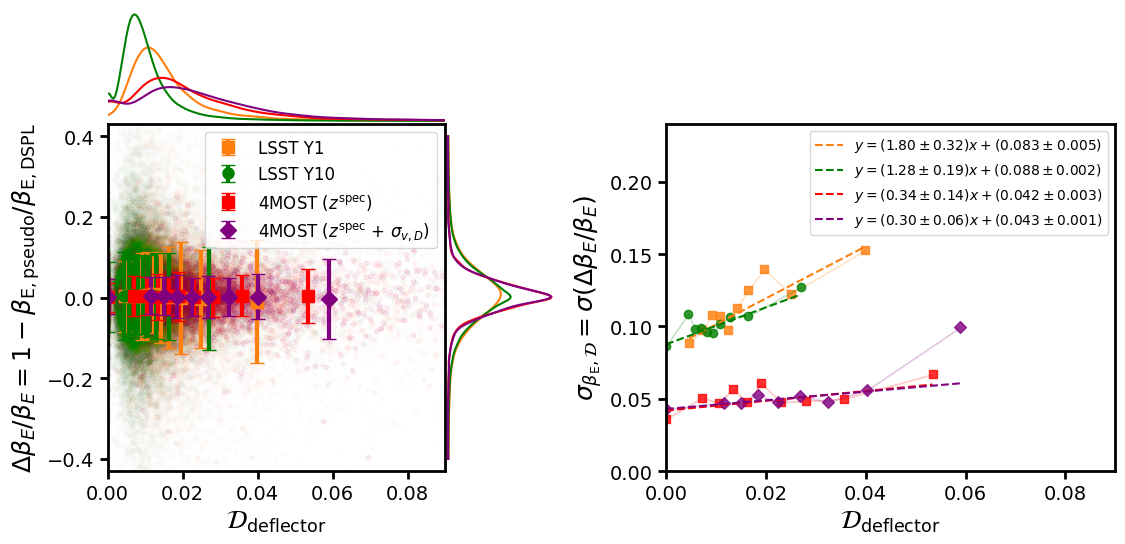

In [6]:
########################################################
# Plot Scatter in Beta E vs Dissimilarity
########################################################
fig_linear = plot_beta_E_vs_D_MC(
    pdspl_samples, 
    mc_results, 
    fit_type='linear', 
    save_path=None,
    show_fit_eqn_label=True
)